In [ ]:
print("Hello World")

Hello World


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install numpy

In [ ]:
import numpy as np

In [ ]:
arr = np.array([1, 2, 3, 4])
print(arr)

[1 2 3 4]


In [ ]:
pip install pandas

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

In [ ]:
pip install scikit-learn

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [ ]:
!pip install kaggle
!kaggle dataset download uciml/pima-indians-diabetes-database
!unzip pima-indians-diabetes-database.zip

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
unzip:  cannot find or open pima-indians-diabetes-database.zip, pima-indians-diabetes-database.zip.zip or pima-indians-diabetes-database.zip.ZIP.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
import pandas as pd


data = pd.read_csv("/content/drive/MyDrive/diabetes.csv")
# Google Colab
# Display the first few rows
print(data.head())

# Summary of the dataset
print(data.info())
print(data.describe())

# Check for missing values
print(data.isnull().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [ ]:
# Separate features (X) and target (y)
X = data.drop("Outcome", axis=1)  # Features
y = data["Outcome"]  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (614, 8)
Testing data shape: (154, 8)


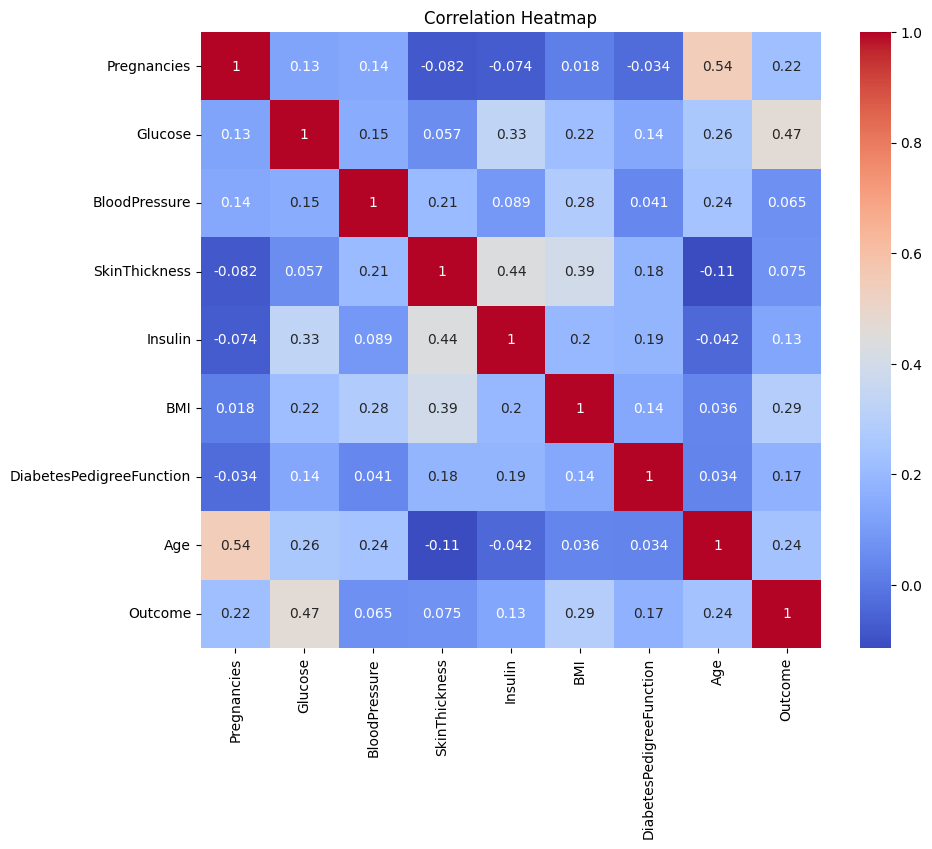

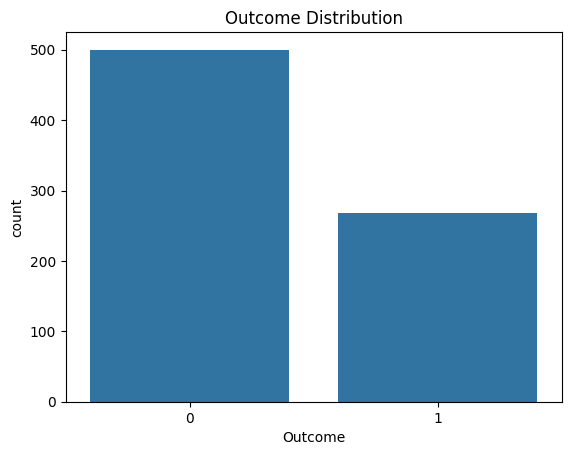

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histogram of outcomes (diabetes or no diabetes)
sns.countplot(x='Outcome', data=data)
plt.title("Outcome Distribution")
plt.show()


In [ ]:
# Initialize and train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)


In [ ]:
import joblib

# Save the model
joblib.dump(model, "diabetes_model.pkl")

# Load the model
loaded_model = joblib.load("diabetes_model.pkl")
new_prediction = loaded_model.predict(X_test[:5])
print("New Predictions:", new_prediction)


New Predictions: [0 0 0 0 0]


Accuracy: 0.7207792207792207


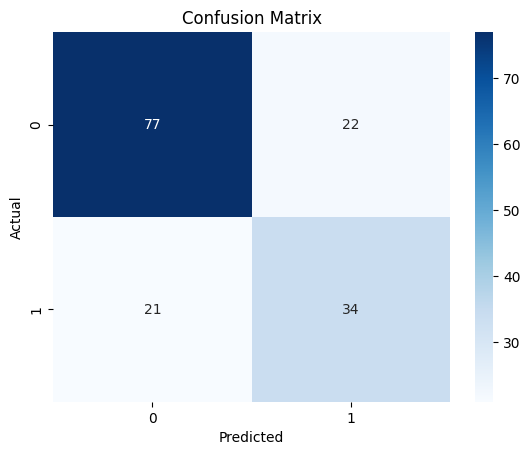

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [ ]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


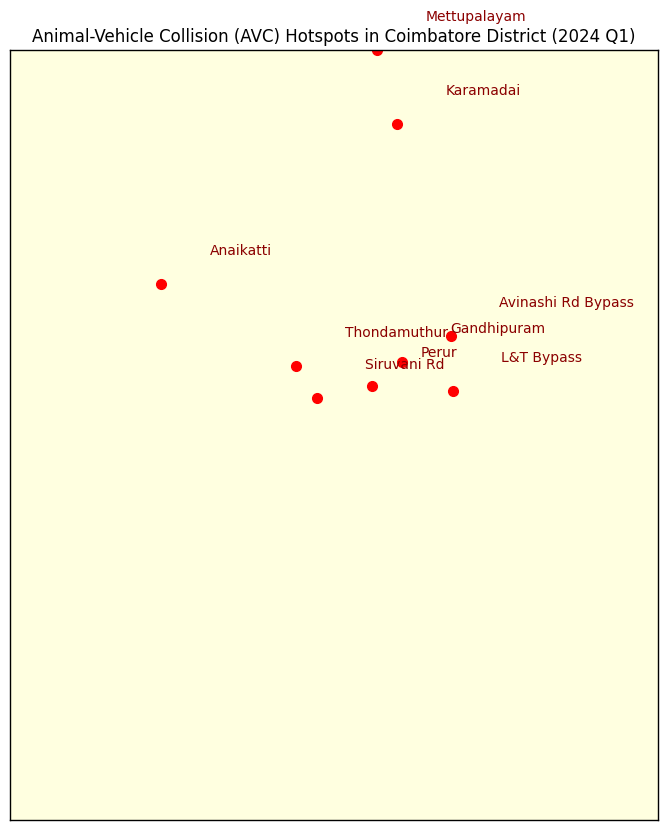

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

plt.figure(figsize=(12, 10))

m = Basemap(projection='merc',
            llcrnrlat=10.6, urcrnrlat=11.3,
            llcrnrlon=76.6, urcrnrlon=77.2,
            resolution='i')

m.drawmapboundary(fill_color='lightblue')
m.fillcontinents(color='lightyellow', lake_color='lightblue')
m.drawcoastlines()
m.drawcountries()
m.drawstates()
m.drawrivers()

# AVC hotspot coordinates
hotspots = {
    "Anaikatti": (76.740, 11.087),
    "Thondamuthur": (76.865, 11.013),
    "Perur": (76.935, 10.995),
    "Siruvani Rd": (76.884, 10.984),
    "Mettupalayam": (76.940, 11.300),
    "Karamadai": (76.958, 11.233),
    "Avinashi Rd Bypass": (77.008, 11.040),
    "Gandhipuram": (76.963, 11.017),
    "L&T Bypass": (77.010, 10.990)
}

for location, (lon, lat) in hotspots.items():
    x, y = m(lon, lat)
    m.plot(x, y, 'ro', markersize=7)
    plt.text(x + 5000, y + 3000, location, fontsize=10, color='darkred')

plt.title("Animal-Vehicle Collision (AVC) Hotspots in Coimbatore District (2024 Q1)")
plt.show()

In [ ]:
!pip install basemap basemap-data-hires

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


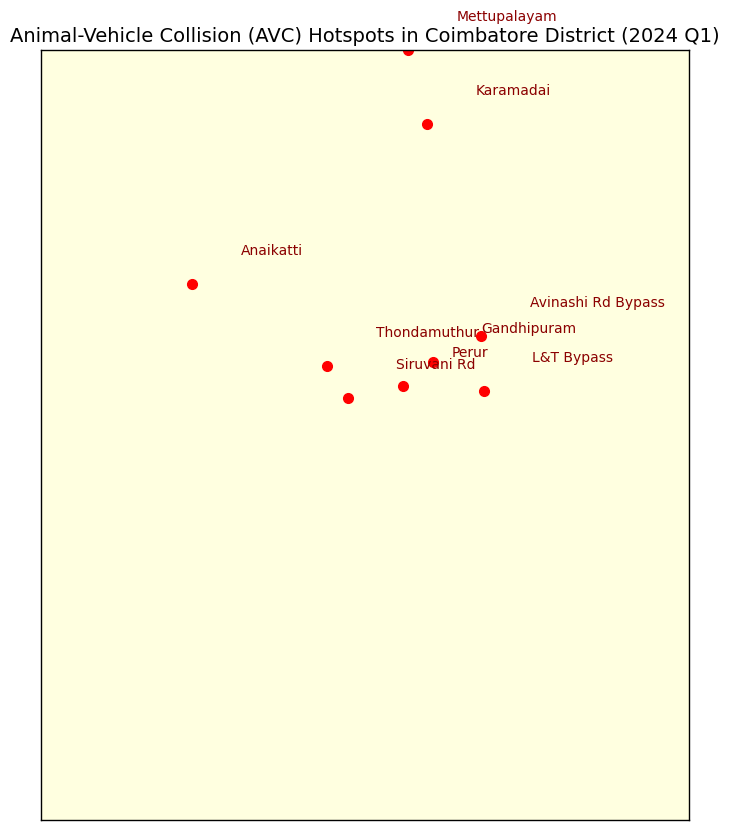

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# Create the map
plt.figure(figsize=(12, 10))
m = Basemap(projection='merc',
            llcrnrlat=10.6, urcrnrlat=11.3,
            llcrnrlon=76.6, urcrnrlon=77.2,
            resolution='i')

# Draw base layers
m.drawmapboundary(fill_color='lightblue')
m.fillcontinents(color='lightyellow', lake_color='lightblue')
m.drawcoastlines()
m.drawcountries()
m.drawstates()
m.drawrivers()


# AVC hotspot coordinates (approximate)
hotspots = {
    "Anaikatti": (76.740, 11.087),
    "Thondamuthur": (76.865, 11.013),
    "Perur": (76.935, 10.995),
    "Siruvani Rd": (76.884, 10.984),
    "Mettupalayam": (76.940, 11.300),
    "Karamadai": (76.958, 11.233),
    "Avinashi Rd Bypass": (77.008, 11.040),
    "Gandhipuram": (76.963, 11.017),
    "L&T Bypass": (77.010, 10.990)
}

# Plot the AVC points
for location, (lon, lat) in hotspots.items():
    x, y = m(lon, lat)
    m.plot(x, y, 'ro', markersize=7)
    plt.text(x + 5000, y + 3000, location, fontsize=10, color='darkred')

# Add title
plt.title("Animal-Vehicle Collision (AVC) Hotspots in Coimbatore District (2024 Q1)", fontsize=14)
plt.show()

In [ ]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Area-wise AVC details
hotspot_data = [
    ("Anaikatti–Thondamuthur Road", ["Wild deer", "Small mammal"], 15),
    ("Perur–Siruvani Road", ["Cattle", "Dog"], 8),
    ("Mettupalayam–Karamadai SH", ["Sheep", "Goat"], 7),
    ("Avinashi Rd Bypass (urban)", ["Dog", "Cattle"], 4),
    ("Gandhipuram / L&T bypass area", ["Dog"], 5)
]

road_types = {
    "Anaikatti–Thondamuthur Road": "Forest Road",
    "Perur–Siruvani Road": "Village Road",
    "Mettupalayam–Karamadai SH": "State Highway",
    "Avinashi Rd Bypass (urban)": "Urban Road",
    "Gandhipuram / L&T bypass area": "Urban Road"
}

# Other options
times_of_day = ["Morning", "Afternoon", "Evening", "Night", "Early Morning"]
weather_conditions = ["Clear", "Rainy", "Foggy", "Cloudy"]
driver_faults = ["Speeding", "Distracted", "Drunk", "Overtaking", "None"]
light_conditions = ["Daylight", "Street Lights", "No Lights", "Low Visibility"]

start_date = datetime(2024, 1, 1)
records = []

# Generate ~100 records per hotspot
for area, animals, approx_count in hotspot_data:
    for i in range(approx_count * 20):
        record = {
            "Accident_ID": f"{area[:3].upper()}_{i+1:04d}",
            "Date": (start_date + timedelta(days=random.randint(0, 90))).strftime('%Y-%m-%d'),
            "Time": random.choice(times_of_day),
            "Location": area,
            "Animal_Type": random.choice(animals),
            "Road_Type": road_types[area],
            "Injury_Severity": random.choice(["Minor", "Grievous", "Fatal"]),
            "Weather": random.choice(weather_conditions),
            "Driver_Fault": random.choice(driver_faults),
            "Light_Condition": random.choice(light_conditions),
            "Latitude": round(random.uniform(10.9, 11.3), 6),
            "Longitude": round(random.uniform(76.8, 77.2), 6)
        }
        records.append(record)

# Create and save DataFrame
df = pd.DataFrame(records)
df.to_csv("AVC_Hotspot_Based_Coimbatore_Q1_2024.csv", index=False)
